# Mean Shift (Modele a noyau de densite)

**Dataset** : Wholesale Customers (UCI) - 440 echantillons, 6 variables de depense  
**Objectif** : Clustering non supervise avec Mean Shift, evaluation via Silhouette, Calinski-Harabasz et Davies-Bouldin  
**Librairies** : scikit-learn, numpy, matplotlib, pandas, seaborn

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

import kagglehub

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

Path to dataset files: C:\Users\afagn\.cache\kagglehub\datasets\binovi\wholesale-customers-data-set\versions\1
Dataset complet: 440 echantillons
Train: 308 | Validation: 66 | Test: 66
Classes de reference (Channel): 2
Variance expliquee PCA 2D: 0.715
Variance expliquee PCA 6D: 1.000


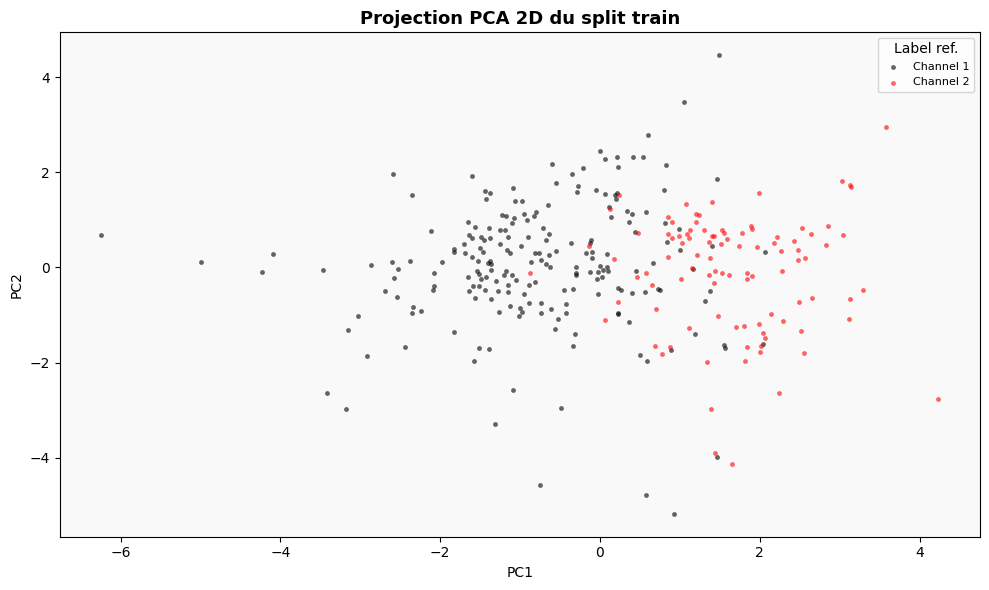

In [2]:
# Chargement des donnees (KaggleHub)
path = kagglehub.dataset_download('binovi/wholesale-customers-data-set')
print('Path to dataset files:', path)

csv_files = list(Path(path).rglob('*.csv'))
if len(csv_files) == 0:
    raise FileNotFoundError('Aucun fichier CSV trouve dans le dataset KaggleHub.')

df = pd.read_csv(csv_files[0])

# Harmonisation des noms de colonnes selon les variantes de source
rename_map = {
    'Detergents_Paper ': 'Detergents_Paper',
    'Detergents_Paper\r': 'Detergents_Paper',
    'Delicatessen': 'Delicassen'
}
df = df.rename(columns=rename_map)

features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
missing = [c for c in features if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes: {missing}")

# Label de reference (non supervise) pour ARI/NMI: Channel
if 'Channel' in df.columns:
    y_raw = df['Channel'].astype(int).values
else:
    y_raw = np.zeros(len(df), dtype=int)

X_raw = df[features].astype(float).values

# Split train 70%, validation 15%, test 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw,
    test_size=0.30,
    stratify=y_raw if len(np.unique(y_raw)) > 1 else None,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp if len(np.unique(y_temp)) > 1 else None,
    random_state=42
)

print(f"Dataset complet: {X_raw.shape[0]} echantillons")
print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Classes de reference (Channel): {len(np.unique(y_raw))}")

# Log1p + Standardisation sur train uniquement
X_train_log = np.log1p(X_train)
X_val_log = np.log1p(X_val)
X_test_log = np.log1p(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_val_scaled = scaler.transform(X_val_log)
X_test_scaled = scaler.transform(X_test_log)

# PCA 2D pour visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)
X_val_pca2 = pca_2d.transform(X_val_scaled)
X_test_pca2 = pca_2d.transform(X_test_scaled)

# PCA ND pour clustering (style 062)
pca_nd_components = min(6, X_train_scaled.shape[1])
pca_nd = PCA(n_components=pca_nd_components, random_state=42)
X_train_pca_nd = pca_nd.fit_transform(X_train_scaled)
X_val_pca_nd = pca_nd.transform(X_val_scaled)
X_test_pca_nd = pca_nd.transform(X_test_scaled)

print(f"Variance expliquee PCA 2D: {pca_2d.explained_variance_ratio_.sum():.3f}")
print(f"Variance expliquee PCA {pca_nd_components}D: {pca_nd.explained_variance_ratio_.sum():.3f}")

# Couleurs imposees: Channel 1 -> noir, Channel 2 -> rouge
unique_classes = np.sort(np.unique(y_train))
base_colors = ['black', 'red']
label_to_color = {cls: base_colors[i % len(base_colors)] for i, cls in enumerate(unique_classes)}

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
for cls in unique_classes:
    mask = y_train == cls
    ax.scatter(
        X_train_pca2[mask, 0],
        X_train_pca2[mask, 1],
        c=label_to_color[cls],
        label=f'Channel {cls}',
        s=12,
        alpha=0.6,
        linewidths=0
    )

ax.set_title('Projection PCA 2D du split train', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Label ref.', fontsize=8, loc='upper right')
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

In [8]:
# Tuning Mean Shift: intervalles continus + moins d'evaluations
ari_min = 0.50
nmi_min = 0.50

n_internal_splits = 8
min_valid_splits = 2
bad_splits_limit = 5
max_evaluations = 70

rng = np.random.default_rng(42)

# Intervalles continus (pas de grille discrete)
quantile_range = (0.03, 0.55)
bw_factor_range = (0.65, 1.80)

candidate_params = []
for _ in range(max_evaluations):
    candidate_params.append({
        'quantile': float(rng.uniform(*quantile_range)),
        'bw_factor': float(rng.uniform(*bw_factor_range)),
        'bin_seeding': bool(rng.integers(0, 2)),
        'cluster_all': bool(rng.integers(0, 2)),
        'bw_seed': int(rng.integers(1, 5000))
    })

print('Intervalles de tuning proposes')
print(f'quantile: [{quantile_range[0]:.2f} .. {quantile_range[1]:.2f}]')
print(f'bandwidth factor: [{bw_factor_range[0]:.2f} .. {bw_factor_range[1]:.2f}]')
print('bin_seeding: aleatoire {True, False}')
print('cluster_all: aleatoire {True, False}')
print(f'Nombre de combinaisons teste: {len(candidate_params)}')
print(f'Multi-splits internes: {n_internal_splits}')
print(f'Splits valides minimum requis: {min_valid_splits}')
print(f'Arret anticipe apres {bad_splits_limit} splits sous seuils')
print(f'Filtre minimum validation ARI: {ari_min}')
print(f'Filtre minimum validation NMI: {nmi_min}')
print()


def evaluate_split(name, X, y_true, labels):
    n_clusters = len(set(labels))
    n_noise = 0
    noise_ratio = 0.0

    print(f'{name}')
    print(f'Clusters detectes: {n_clusters}')
    print(f'Points de bruit: {n_noise} ({noise_ratio:.2%})')

    if len(np.unique(labels)) < 2:
        print('Metriques non disponibles: pas assez de clusters valides')
        print()
        return {
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'ari': np.nan,
            'nmi': np.nan,
            'silhouette': np.nan,
            'valid': False
        }

    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    sil = silhouette_score(X, labels, sample_size=min(1000, len(X)), random_state=42)

    print(f'ARI: {ari:.4f}')
    print(f'NMI: {nmi:.4f}')
    print(f'Silhouette: {sil:.4f}')
    print()

    return {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio,
        'ari': ari,
        'nmi': nmi,
        'silhouette': sil,
        'valid': True
    }


def validation_score(metrics, ari_minimum, nmi_minimum):
    if not metrics['valid']:
        return -1e9, False, 'invalid_metrics'

    if metrics['ari'] < ari_minimum or metrics['nmi'] < nmi_minimum:
        return -1e6 + metrics['ari'] + metrics['nmi'], False, 'below_thresholds'

    cluster_alignment = 1 - min(abs(metrics['n_clusters'] - 2), 10) / 10
    sil_norm = (metrics['silhouette'] + 1.0) / 2.0
    score = 0.35 * metrics['ari'] + 0.30 * metrics['nmi'] + 0.20 * sil_norm + 0.15 * cluster_alignment
    return score, True, 'eligible'


X_pool = np.vstack([X_train_pca_nd, X_val_pca_nd])
y_pool = np.concatenate([y_train, y_val])

if len(np.unique(y_pool)) > 1:
    splitter = StratifiedShuffleSplit(n_splits=n_internal_splits, test_size=0.25, random_state=42)
    split_indices = list(splitter.split(X_pool, y_pool))
else:
    split_indices = []
    for _ in range(n_internal_splits):
        idx = rng.permutation(len(X_pool))
        cut = int(0.75 * len(idx))
        split_indices.append((idx[:cut], idx[cut:]))

results = []
total = len(candidate_params)

for trial, params in enumerate(candidate_params, start=1):
    quantile = params['quantile']
    bw_factor = params['bw_factor']
    bin_seeding = params['bin_seeding']
    cluster_all = params['cluster_all']
    bw_seed = params['bw_seed']

    split_aris, split_nmis, split_sils, split_clusters = [], [], [], []
    valid_split_count = 0
    bad_split_count = 0

    for tr_idx, va_idx in split_indices:
        X_tr, X_va = X_pool[tr_idx], X_pool[va_idx]
        y_va = y_pool[va_idx]

        base_bw = estimate_bandwidth(
            X_tr,
            quantile=quantile,
            n_samples=min(len(X_tr), 280),
            random_state=bw_seed
        )

        if base_bw <= 0:
            continue

        bandwidth = float(base_bw * bw_factor)
        if bandwidth <= 0:
            continue

        model = MeanShift(
            bandwidth=bandwidth,
            bin_seeding=bin_seeding,
            cluster_all=cluster_all
        )

        labels_tr = model.fit_predict(X_tr)
        if len(np.unique(labels_tr)) < 2:
            continue

        labels_va = model.predict(X_va)
        if len(np.unique(labels_va)) < 2:
            continue

        ari = adjusted_rand_score(y_va, labels_va)
        nmi = normalized_mutual_info_score(y_va, labels_va)
        sil = silhouette_score(X_va, labels_va, sample_size=min(1000, len(X_va)), random_state=42)

        split_aris.append(ari)
        split_nmis.append(nmi)
        split_sils.append(sil)
        split_clusters.append(len(np.unique(labels_va)))
        valid_split_count += 1

        if ari < ari_min or nmi < nmi_min:
            bad_split_count += 1
            if valid_split_count >= min_valid_splits and bad_split_count >= bad_splits_limit:
                break

    if valid_split_count < min_valid_splits:
        print(f'Essai {trial}/{total}: splits valides insuffisants ({valid_split_count}) -> rejete')
        continue

    metrics_val = {
        'n_clusters': int(np.round(np.mean(split_clusters))),
        'n_noise': 0,
        'noise_ratio': 0.0,
        'ari': float(np.mean(split_aris)),
        'nmi': float(np.mean(split_nmis)),
        'silhouette': float(np.mean(split_sils)),
        'ari_std': float(np.std(split_aris)),
        'nmi_std': float(np.std(split_nmis)),
        'silhouette_std': float(np.std(split_sils)),
        'valid': True,
        'valid_split_count': valid_split_count
    }

    score_val, eligible_val, eligibility_reason = validation_score(metrics_val, ari_min, nmi_min)

    base_final_bw = estimate_bandwidth(
        X_train_pca_nd,
        quantile=quantile,
        n_samples=min(len(X_train_pca_nd), 280),
        random_state=bw_seed
    )
    if base_final_bw <= 0:
        continue

    final_bandwidth = float(base_final_bw * bw_factor)
    if final_bandwidth <= 0:
        continue

    trial_params = {
        'quantile': quantile,
        'bw_factor': bw_factor,
        'bandwidth': final_bandwidth,
        'bin_seeding': bin_seeding,
        'cluster_all': cluster_all,
        'bw_seed': bw_seed
    }

    results.append({
        'trial': trial,
        'params': trial_params,
        'score_val': float(score_val),
        'eligible_val': bool(eligible_val),
        'eligibility_reason': eligibility_reason,
        'metrics_val': metrics_val
    })

    status = 'eligible' if eligible_val else 'rejete'
    print(f"Essai {trial}/{total} score={score_val:.4f} {status} | q={quantile:.3f} | f={bw_factor:.3f} | bw={final_bandwidth:.4f} | splits={valid_split_count}")

if len(results) == 0:
    raise ValueError('Aucune combinaison exploitable n a ete evaluee.')

eligible_results = [r for r in results if r['eligible_val']]
if len(eligible_results) > 0:
    results_sorted = sorted(eligible_results, key=lambda x: x['score_val'], reverse=True)
    print(f"Combinaisons eligibles: {len(eligible_results)} sur {len(results)}")
else:
    # Pas d'erreur bloquante: on prend la meilleure combinaison non eligible
    results_sorted = sorted(results, key=lambda x: x['score_val'], reverse=True)
    print('Aucune combinaison n atteint ARI/NMI 0.50: selection de la meilleure combinaison de secours.')

best_result = results_sorted[0]
best_params = best_result['params']

print('Top 5 combinaisons validation')
for rank, item in enumerate(results_sorted[:5], start=1):
    m = item['metrics_val']
    p = item['params']
    print(f"{rank}. score={item['score_val']:.4f} | q={p['quantile']:.3f} | f={p['bw_factor']:.3f} | bw={p['bandwidth']:.4f} | ARI={m['ari']:.4f} | NMI={m['nmi']:.4f} | SIL={m['silhouette']:.4f}")

print()
print('Meilleure combinaison retenue pour le modele final')
print(best_params)
print()
print('Le test est reserve a la fin et execute dans la cellule finale uniquement.')

ms_train = MeanShift(
    bandwidth=best_params['bandwidth'],
    bin_seeding=best_params['bin_seeding'],
    cluster_all=best_params['cluster_all']
)
labels_train = ms_train.fit_predict(X_train_pca_nd)
train_metrics = evaluate_split('Train', X_train_pca_nd, y_train, labels_train)
labels_val = ms_train.predict(X_val_pca_nd)
val_metrics = evaluate_split('Validation avec meilleure combinaison', X_val_pca_nd, y_val, labels_val)

cluster_ids_train, cluster_sizes_train = np.unique(labels_train, return_counts=True)
n_clusters_train = len(cluster_ids_train)
n_noise_train = 0
noise_ratio_train = 0.0

Intervalles de tuning proposes
quantile: [0.03 .. 0.55]
bandwidth factor: [0.65 .. 1.80]
bin_seeding: aleatoire {True, False}
cluster_all: aleatoire {True, False}
Nombre de combinaisons teste: 70
Multi-splits internes: 8
Splits valides minimum requis: 2
Arret anticipe apres 5 splits sous seuils
Filtre minimum validation ARI: 0.5
Filtre minimum validation NMI: 0.5

Essai 1/70 score=-999999.9993 rejete | q=0.432 | f=1.155 | bw=3.3645 | splits=5
Essai 2/70 score=-999999.9996 rejete | q=0.079 | f=1.772 | bw=3.0829 | splits=5
Essai 3/70 score=-999999.8537 rejete | q=0.439 | f=0.797 | bw=2.2845 | splits=5
Essai 4/70 score=-999999.9992 rejete | q=0.512 | f=1.390 | bw=4.3272 | splits=3
Essai 5/70 score=-999999.8138 rejete | q=0.261 | f=0.911 | bw=2.1599 | splits=5
Essai 6/70 score=-999999.9992 rejete | q=0.460 | f=1.376 | bw=4.0887 | splits=5
Essai 7/70 score=-999999.9993 rejete | q=0.214 | f=1.766 | bw=4.0259 | splits=5
Essai 8/70 score=-999999.8536 rejete | q=0.131 | f=1.187 | bw=2.3172 | sp

In [10]:
if 'test_final_deja_fait'  in globals():
    test_final_deja_fait = False

if test_final_deja_fait:
    print('Test final deja execute dans cette session. Redemarre le kernel pour le relancer.')
else:
    ms_test_final = MeanShift(
        bandwidth=best_params['bandwidth'],
        bin_seeding=best_params['bin_seeding'],
        cluster_all=best_params['cluster_all']
    )
    ms_test_final.fit(X_train_pca_nd)
    labels_test = ms_test_final.predict(X_test_pca_nd)
    evaluate_split('Test final', X_test_pca_nd, y_test, labels_test)
    test_final_deja_fait = True
    print('Test final execute une seule fois pour cette session.')
    print('Hyperparametres utilises pour le test final')
    print(best_params)

Test final
Clusters detectes: 12
Points de bruit: 0 (0.00%)
ARI: 0.0394
NMI: 0.1972
Silhouette: -0.0870

Test final execute une seule fois pour cette session.
Hyperparametres utilises pour le test final
{'quantile': 0.22430201901432925, 'bw_factor': 0.7586366682707426, 'bandwidth': 1.7134708796822835, 'bin_seeding': True, 'cluster_all': True, 'bw_seed': 3734}


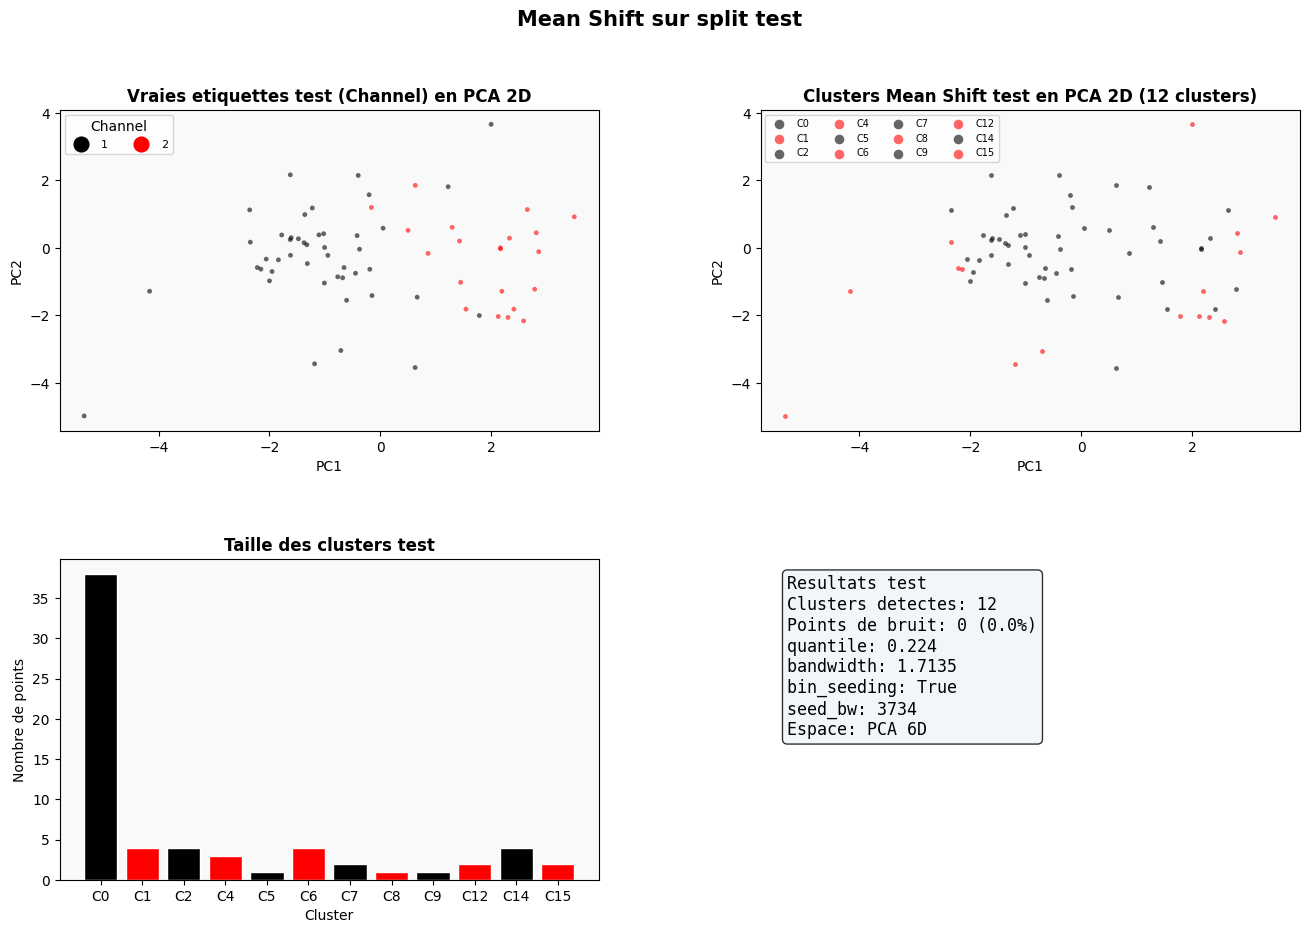

In [11]:
# Visualisation des resultats du split test
if 'labels_test' not in globals():
    print('Les labels du test ne sont pas encore calcules. Execute d abord la cellule de test final.')
else:
    cluster_ids_test, cluster_sizes_test = np.unique(labels_test, return_counts=True)
    n_clusters_test = len(cluster_ids_test)
    n_noise_test = 0
    noise_ratio_test = 0.0

    # Couleurs imposees noir/rouge
    pred_colors = ['black', 'red']
    pred_color_map = {cid: pred_colors[i % len(pred_colors)] for i, cid in enumerate(np.sort(cluster_ids_test))}

    point_colors_pred_test = np.array([pred_color_map[l] for l in labels_test])
    point_colors_true_test = np.array([label_to_color[c] for c in y_test])

    fig = plt.figure(figsize=(16, 10), facecolor='white')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(X_test_pca2[:, 0], X_test_pca2[:, 1], c=point_colors_true_test, s=12, alpha=0.6, linewidths=0)
    ax1.set_title('Vraies etiquettes test (Channel) en PCA 2D', fontsize=12, fontweight='bold')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_facecolor('#f9f9f9')
    for cls in unique_classes:
        ax1.scatter([], [], c=label_to_color[cls], label=str(cls), s=50)
    ax1.legend(title='Channel', ncol=2, fontsize=8, markerscale=1.5)

    ax2 = fig.add_subplot(gs[0, 1])
    for cid in np.sort(cluster_ids_test):
        mask_c = labels_test == cid
        ax2.scatter(
            X_test_pca2[mask_c, 0],
            X_test_pca2[mask_c, 1],
            c=pred_color_map[cid],
            s=12,
            alpha=0.6,
            linewidths=0,
            label=f'C{cid}'
        )
    ax2.set_title(f'Clusters Mean Shift test en PCA 2D ({n_clusters_test} clusters)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_facecolor('#f9f9f9')
    ax2.legend(ncol=4, fontsize=7, markerscale=2)

    ax3 = fig.add_subplot(gs[1, 0])
    bar_colors = [pred_color_map[cid] for cid in np.sort(cluster_ids_test)]
    ax3.bar([f'C{cid}' for cid in np.sort(cluster_ids_test)], cluster_sizes_test[np.argsort(cluster_ids_test)], color=bar_colors, edgecolor='white')
    ax3.set_title('Taille des clusters test', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Cluster')
    ax3.set_ylabel('Nombre de points')
    ax3.set_facecolor('#f9f9f9')

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    metrics_text = (
        f"Resultats test\n"
        f"Clusters detectes: {n_clusters_test}\n"
        f"Points de bruit: {n_noise_test} ({noise_ratio_test:.1%})\n"
        f"quantile: {best_params['quantile']:.3f}\n"
        f"bandwidth: {best_params['bandwidth']:.4f}\n"
        f"bin_seeding: {best_params['bin_seeding']}\n"
        f"seed_bw: {best_params.get('bw_seed', 'n/a')}\n"
        f"Espace: PCA {pca_nd_components}D"
    )
    ax4.text(
        0.05,
        0.95,
        metrics_text,
        transform=ax4.transAxes,
        fontsize=12,
        verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8)
    )
    ax4.set_facecolor('white')

    plt.suptitle('Mean Shift sur split test', fontsize=15, fontweight='bold')
    plt.show()